# CBAM y cabeza de detección implementados

Attention not only tells where to focus, it also improves the representation of interests. Our goal is to increase representation
power by using attention mechanism: focusing on important features and suppressing unnecessary ones.
we adopt our module to emphasize meaningful features along those two
principal dimensions: channel and spatial axes. To achieve this, we sequentially
apply channel and spatial attention modules, so that each of the branches can learn ‘what’ and ‘where’ to attend in the channel and spatial axes respectively. As a result, our module efficiently helps the information flow within the network by learning which information to emphasize or suppress.

CBAM: Convolutional Block Attention Module Sanghyun Woo, Jongchan Park, Joon-Young Lee and In So Kweon
https://arxiv.org/pdf/1807.06521

CBAM also gives weights to every single pixel in the spatial dimension of the image 
 CBAM consists of CAM and SAM. These two sub-blocks are responsible for creating attention weights, which will then be applied to the original tensor by multiplication. The output tensor of this block (the one referred to as Refined Features) has the exact same dimension as the input (Input Feature), meaning that we can easily plug CBAM to any backbone model without needing to worry about altering the tensor shapes.
 https://towardsdatascience.com/cbam-paper-walkthrough-the-double-attention-mechanism/

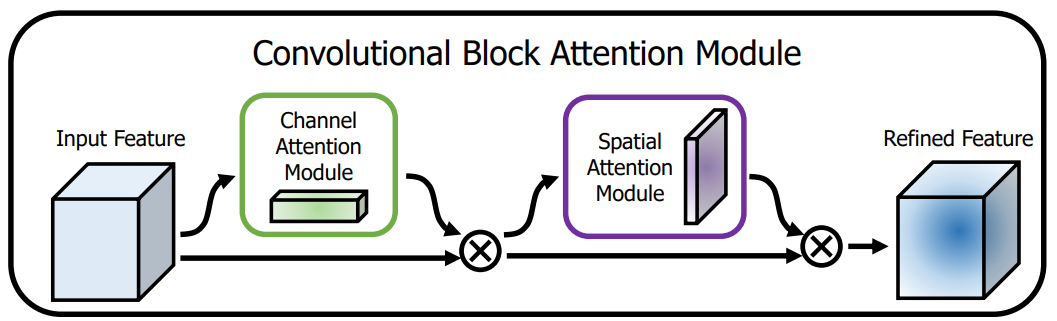

In [49]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

In [50]:
SEED = 42
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
NAMES = ["base", "plus"]
RESULTADOS = {n: {} for n in NAMES}   # se llena en las pruebas y se resume al final
print("torch", torch.__version__, "| dispositivo:", DEVICE)

torch 2.14.1+cpu | dispositivo: cpu


In [51]:
class FundidoraPC(nn.Module):
    """4 bloques Conv3x3 -> BatchNorm -> ReLU -> MaxPool2x2 (version base)."""

    def __init__(self, in_channels=3):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels, 32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        self.pool1 = nn.MaxPool2d(kernel_size=2)

        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        self.pool2 = nn.MaxPool2d(kernel_size=2)

        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(128)
        self.pool3 = nn.MaxPool2d(kernel_size=2)

        self.conv4 = nn.Conv2d(128, 256, kernel_size=3, padding=1)
        self.bn4 = nn.BatchNorm2d(256)
        self.pool4 = nn.MaxPool2d(kernel_size=2)

        self.global_pool = nn.AdaptiveAvgPool2d(output_size=1)
        self.out_features = 256

    def _encode(self, x):
        x = self.pool1(torch.relu(self.bn1(self.conv1(x))))
        x = self.pool2(torch.relu(self.bn2(self.conv2(x))))
        x = self.pool3(torch.relu(self.bn3(self.conv3(x))))
        # Solo 4 MaxPool en total: no agregar pooling extra.
        return self.pool4(torch.relu(self.bn4(self.conv4(x))))

    def forward(self, x):
        feature_map = self._encode(x)                                # [B, 256, H/16, W/16]
        pooled = self.global_pool(feature_map).flatten(start_dim=1)  # [B, 256]
        return pooled, feature_map


In [52]:
class FundidoraPCPlus(FundidoraPC):
    """Base + bloque de contexto a stride 16 (convs dilatadas, residual)."""
    def __init__(self, in_channels=3, dilations=(2, 4)):
        super().__init__(in_channels)
        self.dilations = tuple(dilations)
        layers = []
        for d in self.dilations:
            layers += [nn.Conv2d(256, 256, kernel_size=3, padding=d, dilation=d, bias=False),
                       nn.BatchNorm2d(256), nn.ReLU(inplace=True)]
        self.context = nn.Sequential(*layers)

    def _encode(self, x):
        feature_map = super()._encode(x)
        return feature_map + self.context(feature_map)


def build_backbone(name="base", in_channels=1):
    if name == "base":
        return FundidoraPC(in_channels=in_channels)
    if name == "plus":
        return FundidoraPCPlus(in_channels=in_channels)
    raise ValueError(f"backbone desconocido: {name!r}")


BASE_LAYERS = [(3, 1, 1), (2, 2, 1)] * 4          # (kernel, stride, dilation)
PLUS_LAYERS = BASE_LAYERS + [(3, 1, 2), (3, 1, 4)]
LAYERS = {"base": BASE_LAYERS, "plus": PLUS_LAYERS}

def theoretical_receptive_field(layers):
    r, j = 1, 1
    for k, s, d in layers:
        r += (k - 1) * d * j
        j *= s
    return r, j

def count_parameters(model):
    return sum(p.numel() for p in model.parameters())


def make_models(train=False):
    out = {}
    for n in NAMES:
        torch.manual_seed(SEED)
        m = build_backbone(n, in_channels=1).to(DEVICE)
        out[n] = m.train() if train else m.eval()
    return out

MODELS = make_models()
for n, m in MODELS.items():
    RESULTADOS[n]["parametros"] = count_parameters(m)
    RESULTADOS[n]["rf_teorico"] = theoretical_receptive_field(LAYERS[n])[0]
    print(f"{n:5s} parametros = {count_parameters(m):>9,} | RF teorico = {RESULTADOS[n]['rf_teorico']} px")

base  parametros =   388,800 | RF teorico = 46 px
plus  parametros = 1,569,472 | RF teorico = 238 px


In [53]:
class ChannelAttention(nn.Module):
    def __init__(self, channels, reduction=16):
        super().__init__()
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.max_pool = nn.AdaptiveMaxPool2d(1)
        hidden = max(channels // reduction, 8)
        self.mlp = nn.Sequential(
            nn.Conv2d(channels, hidden, kernel_size=1, bias=False),
            nn.ReLU(inplace=True),
            nn.Conv2d(hidden, channels, kernel_size=1, bias=False),
        )
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        avg_out = self.mlp(self.avg_pool(x))
        max_out = self.mlp(self.max_pool(x))
        return self.sigmoid(avg_out + max_out)  # [B, C, 1, 1]


class SpatialAttention(nn.Module):
    def __init__(self, kernel_size=7):
        super().__init__()
        self.conv = nn.Conv2d(2, 1, kernel_size=kernel_size, padding=kernel_size // 2, bias=False)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        avg_out = x.mean(dim=1, keepdim=True)
        max_out, _ = x.max(dim=1, keepdim=True)
        concat = torch.cat([avg_out, max_out], dim=1)
        return self.sigmoid(self.conv(concat))  # [B, 1, H, W]


class CBAM(nn.Module):
    """Secuencial: primero atencion de canal, luego atencion espacial sobre el resultado."""
    def __init__(self, channels, reduction=16, spatial_kernel=7):
        super().__init__()
        self.channel_attention = ChannelAttention(channels, reduction)
        self.spatial_attention = SpatialAttention(spatial_kernel)

    def forward(self, x):
        channel_attn = self.channel_attention(x)
        x_channel = x * channel_attn
        spatial_attn = self.spatial_attention(x_channel)
        x_out = x_channel * spatial_attn
        return x_out, channel_attn, spatial_attn


def build_cbam_modules(channels=256, reduction=16, spatial_kernel=7):
    modules = {}
    for name in NAMES:
        torch.manual_seed(SEED)
        modules[name] = CBAM(channels, reduction, spatial_kernel).to(DEVICE)
    return modules

CBAM_MODULES = build_cbam_modules()
for name, cbam in CBAM_MODULES.items():
    n_params = count_parameters(cbam)
    RESULTADOS[name]["cbam_parametros"] = n_params
    print(f"[{name}] CBAM parametros = {n_params:,}")

[base] CBAM parametros = 8,290
[plus] CBAM parametros = 8,290


In [54]:
class CompuertaResidualCBAM(nn.Module):
    """y = x + gamma * (CBAM(x) - x), con gamma inicializado en 0.
    Con gamma=0, y = x exactamente: insertar CBAM no cambia nada al inicio.
    La red decide, durante el entrenamiento, cuanto usar la atencion."""
    def __init__(self, cbam):
        super().__init__()
        self.cbam = cbam
        self.gamma = nn.Parameter(torch.zeros(1))

    def forward(self, x):
        x_cbam, ch_attn, sp_attn = self.cbam(x)
        y = x + self.gamma * (x_cbam - x)
        return y, ch_attn, sp_attn

### Prueba 1: forma preservada

CBAM no debe alterar la forma del feature map, solo reponderarlo. Se verifica que
la salida tenga exactamente la misma forma que la entrada, y que los mapas de
atencion tengan las formas esperadas: [B, 256, 1, 1] para canal, [B, 1, 16, 16] para espacial.

In [55]:
for name, m in MODELS.items():
    cbam = CBAM_MODULES[name]
    with torch.no_grad():
        _, fmap = m(torch.rand(4, 1, 256, 256, device=DEVICE))
        out, ch_attn, sp_attn = cbam(fmap)

    assert out.shape == fmap.shape, (name, out.shape, fmap.shape)
    assert ch_attn.shape == (4, 256, 1, 1), ch_attn.shape
    assert sp_attn.shape == (4, 1, 16, 16), sp_attn.shape
    assert torch.isfinite(out).all()
    # Sigmoid garantiza rango (0,1) en ambos mapas de atencion
    assert ch_attn.min() >= 0 and ch_attn.max() <= 1
    assert sp_attn.min() >= 0 and sp_attn.max() <= 1

    print(f"[{name}] fmap {tuple(fmap.shape)} -> CBAM out {tuple(out.shape)} "
          f"| canal attn {tuple(ch_attn.shape)} rango=({ch_attn.min():.3f},{ch_attn.max():.3f}) "
          f"| espacial attn {tuple(sp_attn.shape)} rango=({sp_attn.min():.3f},{sp_attn.max():.3f})")

[base] fmap (4, 256, 16, 16) -> CBAM out (4, 256, 16, 16) | canal attn (4, 256, 1, 1) rango=(0.485,0.513) | espacial attn (4, 1, 16, 16) rango=(0.499,0.508)
[plus] fmap (4, 256, 16, 16) -> CBAM out (4, 256, 16, 16) | canal attn (4, 256, 1, 1) rango=(0.486,0.513) | espacial attn (4, 1, 16, 16) rango=(0.499,0.509)


### Prueba 2: gradientes no nulos, de punta a punta

Se verifica que el gradiente fluya correctamente a traves de todo el camino:
backbone -> CBAM -> perdida. Esto confirma que CBAM es entrenable y que no bloquea
la propagacion hacia las capas del backbone (ej. conv1).

In [56]:
for name in NAMES:
    torch.manual_seed(SEED)
    backbone = build_backbone(name, in_channels=1).to(DEVICE).train()
    cbam = CBAM(256).to(DEVICE).train()

    backbone.zero_grad()
    cbam.zero_grad()

    _, fmap = backbone(torch.rand(4, 1, 256, 256, device=DEVICE))
    out, ch_attn, sp_attn = cbam(fmap)
    out.mean().backward()

    # Gradientes del CBAM
    for n, p in cbam.named_parameters():
        assert p.grad is not None, f"CBAM sin gradiente: {n}"
        assert torch.isfinite(p.grad).all(), f"CBAM gradiente no finito: {n}"

    # Gradiente debe llegar hasta la primera capa del backbone (conv1)
    grad_conv1 = backbone.conv1.weight.grad
    assert grad_conv1 is not None, "el gradiente no llego hasta conv1 del backbone"
    assert torch.isfinite(grad_conv1).all()
    assert grad_conv1.norm().item() > 0

    print(f"[{name}] gradiente CBAM OK | norma grad conv1 (backbone) = {grad_conv1.norm().item():.3e}")

[base] gradiente CBAM OK | norma grad conv1 (backbone) = 1.218e-02
[plus] gradiente CBAM OK | norma grad conv1 (backbone) = 3.268e-02


### Prueba 3: comparacion de forward con y sin CBAM

Se compara el feature map antes y despues de CBAM, usando el mismo batch de entrada.
Si CBAM funciona, se debe observar reponderacion real: algunos canales se atenuan
mas que otros (atencion de canal no uniforme), y el mapa espacial debe concentrarse
en regiones especificas (no ser plano/uniforme).

[base] diferencia relativa fmap vs fmap_cbam = 74.77% | std atencion de canal = 0.0051
[plus] diferencia relativa fmap vs fmap_cbam = 74.77% | std atencion de canal = 0.0051


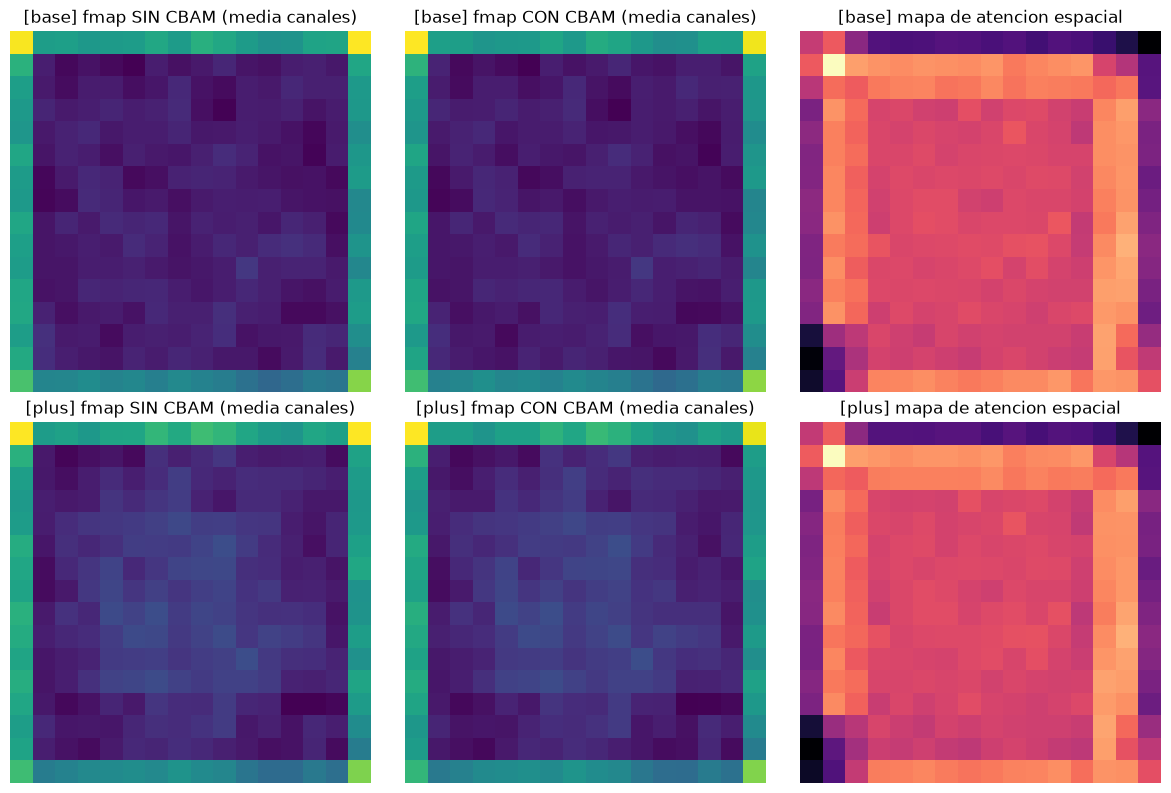

In [57]:
x_test = torch.rand(4, 1, 256, 256, device=DEVICE)

fig, axes = plt.subplots(len(NAMES), 3, figsize=(12, 4 * len(NAMES)))
if len(NAMES) == 1:
    axes = axes[None, :]

for row, name in enumerate(NAMES):
    m = MODELS[name]
    cbam = CBAM_MODULES[name]

    with torch.no_grad():
        _, fmap = m(x_test)
        fmap_cbam, ch_attn, sp_attn = cbam(fmap)

    # Diferencia relativa entre feature map original y con CBAM
    diff_relativa = ((fmap - fmap_cbam).abs().mean() / fmap.abs().mean()).item()
    # Dispersion de la atencion de canal: si es ~0, CBAM no esta discriminando canales
    ch_attn_std = ch_attn.std().item()

    assert diff_relativa > 0.01, f"[{name}] CBAM casi no cambia el feature map (sospechoso)"
    assert ch_attn_std > 0.001, f"[{name}] atencion de canal demasiado uniforme (sospechoso)"

    print(f"[{name}] diferencia relativa fmap vs fmap_cbam = {diff_relativa:.2%} "
          f"| std atencion de canal = {ch_attn_std:.4f}")

    sin_cbam_vis = fmap.mean(dim=1)[0].cpu()
    con_cbam_vis = fmap_cbam.mean(dim=1)[0].cpu()
    sp_attn_vis = sp_attn[0, 0].cpu()

    axes[row, 0].imshow(sin_cbam_vis, cmap="viridis")
    axes[row, 0].set_title(f"[{name}] fmap SIN CBAM (media canales)")
    axes[row, 1].imshow(con_cbam_vis, cmap="viridis")
    axes[row, 1].set_title(f"[{name}] fmap CON CBAM (media canales)")
    axes[row, 2].imshow(sp_attn_vis, cmap="magma")
    axes[row, 2].set_title(f"[{name}] mapa de atencion espacial")
    for ax in axes[row]:
        ax.axis("off")

plt.tight_layout()
plt.show()

### Prueba 4: integracion antes de la cabeza de deteccion

Se conecta backbone -> CBAM -> cabeza, replicando la Prueba 7 del backbone pero
ahora con CBAM en medio. Se confirma que la forma de salida de la cabeza no cambia
(sigue siendo [B, 8, 16, 16]: 1 objectness + 4 caja + 3 clases), y que el gradiente
sigue fluyendo correctamente a traves de las tres piezas juntas.

esta es una integracion preliminar con CBAM crudo (sin compuerta) y una
cabeza simplificada, usada solo para validar que backbone+CBAM+cabeza es compatible
en forma y gradientes. La integracion real del proyecto usa CompuertaResidualCBAM
y GridDetectionHead (ver seccion "4. la cabeza" mas adelante).

In [58]:
head = nn.Conv2d(256, 1 + 4 + 3, kernel_size=1).to(DEVICE)

for name, m in MODELS.items():
    cbam = CBAM_MODULES[name]

    with torch.no_grad():
        _, fmap = m(torch.rand(4, 1, 256, 256, device=DEVICE))
        fmap_cbam, _, _ = cbam(fmap)
        salida = head(fmap_cbam)

    assert salida.shape == (4, 8, 16, 16), salida.shape
    print(f"[{name}] backbone -> CBAM -> cabeza: fmap {tuple(fmap.shape)} "
          f"-> salida {tuple(salida.shape)} OK")

# Gradiente de punta a punta: backbone -> CBAM -> cabeza
torch.manual_seed(SEED)
backbone = build_backbone("base", in_channels=1).to(DEVICE).train()
cbam = CBAM(256).to(DEVICE).train()
head_train = nn.Conv2d(256, 8, kernel_size=1).to(DEVICE)

backbone.zero_grad(); cbam.zero_grad(); head_train.zero_grad()

_, fmap = backbone(torch.rand(4, 1, 256, 256, device=DEVICE))
fmap_cbam, _, _ = cbam(fmap)
salida = head_train(fmap_cbam)
salida.mean().backward()

assert backbone.conv1.weight.grad is not None
assert torch.isfinite(backbone.conv1.weight.grad).all()
print("Gradiente de punta a punta (backbone -> CBAM -> cabeza) OK")

[base] backbone -> CBAM -> cabeza: fmap (4, 256, 16, 16) -> salida (4, 8, 16, 16) OK
[plus] backbone -> CBAM -> cabeza: fmap (4, 256, 16, 16) -> salida (4, 8, 16, 16) OK
Gradiente de punta a punta (backbone -> CBAM -> cabeza) OK


Prueba 5

In [60]:
torch.manual_seed(SEED)
backbone_p5 = build_backbone("base", in_channels=1).to(DEVICE)
cbam_p5 = CompuertaResidualCBAM(CBAM(256)).to(DEVICE)   
head_p5 = nn.Linear(256, 2).to(DEVICE)

# Batch sintetico: la mitad de las imagenes tiene un parche brillante en una
# esquina fija (clase 1), la otra mitad no (clase 0). Señal trivialmente
# separable si el modelo aprende a mirar esa zona.
torch.manual_seed(SEED)
batch_size = 16
x_synth = torch.rand(batch_size, 1, 256, 256, device=DEVICE) * 0.3
y_synth = torch.zeros(batch_size, dtype=torch.long, device=DEVICE)
for i in range(batch_size):
    if i % 2 == 0:
        x_synth[i, 0, 20:60, 20:60] = 1.0
        y_synth[i] = 1

# Atencion de canal y espacial ANTES de entrenar (referencia)
backbone_p5.eval(); cbam_p5.eval()
with torch.no_grad():
    _, fmap0 = backbone_p5(x_synth)
    _, ch_attn0, sp_attn0 = cbam_p5(fmap0)
std_canal_antes = ch_attn0.std().item()

params = list(backbone_p5.parameters()) + list(cbam_p5.parameters()) + list(head_p5.parameters())
optimizer = torch.optim.Adam(params, lr=1e-3)

backbone_p5.train(); cbam_p5.train(); head_p5.train()
losses = []
gammas = []   # <- nueva lista para rastrear gamma
for step in range(150):
    optimizer.zero_grad()
    _, fmap = backbone_p5(x_synth)
    fmap_cbam, ch_attn, sp_attn = cbam_p5(fmap)
    pooled = fmap_cbam.mean(dim=(2, 3))
    logits = head_p5(pooled)
    loss = F.cross_entropy(logits, y_synth)
    loss.backward()
    optimizer.step()
    losses.append(loss.item())
    gammas.append(cbam_p5.gamma.item())   

backbone_p5.eval(); cbam_p5.eval()
with torch.no_grad():
    _, fmap_final = backbone_p5(x_synth)
    _, ch_attn_final, sp_attn_final = cbam_p5(fmap_final)
std_canal_despues = ch_attn_final.std().item()
accuracy_final = (logits.argmax(dim=1) == y_synth).float().mean().item()

print(f"Loss inicial: {losses[0]:.4f} -> Loss final: {losses[-1]:.4f}")
print(f"Accuracy final sobre el batch de entrenamiento: {accuracy_final:.1%}")
print(f"std atencion de canal ANTES de entrenar:  {std_canal_antes:.4f}")
print(f"std atencion de canal DESPUES de entrenar: {std_canal_despues:.4f}")
print(f"gamma inicial: {gammas[0]:.4f} -> gamma final: {gammas[-1]:.4f}")
print("Interpretacion: |gamma| indica cuanto se uso el bloque de atencion; "
      "el signo indica si en sentido normal (positivo) o invertido (negativo).")

assert losses[-1] < losses[0] * 0.5, "el loss no bajo lo suficiente (revisar lr/pasos)"
assert accuracy_final > 0.9, "no se logro overfit sobre el batch pequeño"
assert std_canal_despues > std_canal_antes, "CBAM no se volvio mas discriminativo tras entrenar"
print("CBAM se vuelve discriminativo al entrenar: OK")



Loss inicial: 0.7152 -> Loss final: 0.0001
Accuracy final sobre el batch de entrenamiento: 100.0%
std atencion de canal ANTES de entrenar:  0.0037
std atencion de canal DESPUES de entrenar: 0.4098
gamma inicial: 0.0010 -> gamma final: -0.0264
Interpretacion: |gamma| indica cuanto se uso el bloque de atencion; el signo indica si en sentido normal (positivo) o invertido (negativo).
CBAM se vuelve discriminativo al entrenar: OK


Recordemos que:
1. $|\gamma|$ indica **cuánto** se usa el bloque, y el signo indica **cómo**. Un γ negativo no es un error: el modelo encontró más útil amplificar lo que el bloque suprime que suprimirlo.

2. El mapa espacial de CBAM se lee según el signo de γ en esa etapa. Con γ positivo, las zonas con peso alto son las que el modelo conserva; con γ negativo, las zonas con peso **bajo** son las que el modelo refuerza. Un mapa que parece resaltar el fondo en una etapa con γ negativo es coherente con esa inversión.

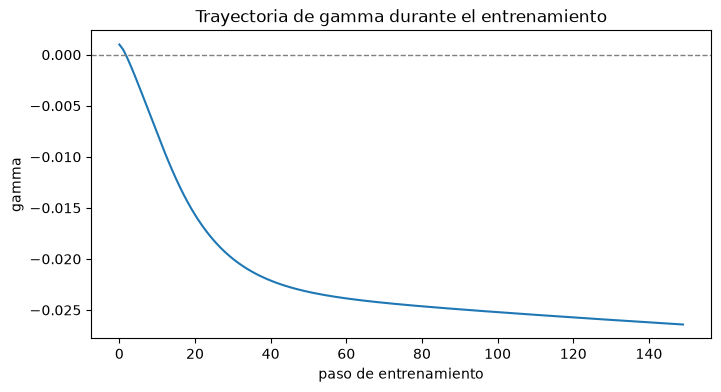

In [61]:
plt.figure(figsize=(8, 4))
plt.plot(gammas)
plt.axhline(0, color="gray", linestyle="--", linewidth=1)
plt.xlabel("paso de entrenamiento")
plt.ylabel("gamma")
plt.title("Trayectoria de gamma durante el entrenamiento")
plt.show()

### 1. IoU y sus 3 pruebas de control
cajas idénticas dan 1, cajas disjuntas dan 0, y un solapamiento conocido (por ejemplo [0,0,10,10] vs [5,0,15,10]) da 1/3. Agrega un caso de caja con área cero que no produzca NaN

In [62]:
def box_iou(boxes1, boxes2, eps=1e-7):
    """IoU elemento a elemento entre cajas en formato xyxy (píxeles).
    Acepta cualquier forma [..., 4] que sea compatible por broadcasting."""
    boxes1 = boxes1.float()
    boxes2 = boxes2.float()

    # 1) Esquinas del rectángulo de intersección
    inter_x1 = torch.maximum(boxes1[..., 0], boxes2[..., 0])
    inter_y1 = torch.maximum(boxes1[..., 1], boxes2[..., 1])
    inter_x2 = torch.minimum(boxes1[..., 2], boxes2[..., 2])
    inter_y2 = torch.minimum(boxes1[..., 3], boxes2[..., 3])

    # 2) Área de la intersección (clamp: si no se tocan, ancho/alto negativo -> 0)
    inter_area = (inter_x2 - inter_x1).clamp(min=0) * (inter_y2 - inter_y1).clamp(min=0)

    # 3) Área de cada caja
    area1 = (boxes1[..., 2] - boxes1[..., 0]).clamp(min=0) * (boxes1[..., 3] - boxes1[..., 1]).clamp(min=0)
    area2 = (boxes2[..., 2] - boxes2[..., 0]).clamp(min=0) * (boxes2[..., 3] - boxes2[..., 1]).clamp(min=0)

    # 4) Unión = suma de áreas - intersección (para no contarla dos veces)
    union = area1 + area2 - inter_area
    return inter_area / (union + eps)


def pairwise_iou(boxes1, boxes2):
    """Matriz [N, M]: IoU de cada caja de boxes1 contra cada caja de boxes2 (la usará el NMS)."""
    return box_iou(boxes1[:, None, :], boxes2[None, :, :])


# ---------------- Pruebas de control ----------------
fallas = []

def check(nombre, obtenido, esperado, tol=1e-5):
    ok = abs(obtenido - esperado) < tol
    print(f"{'OK   ' if ok else 'FALLA'} | {nombre:<40} obtenido={obtenido:.6f}  esperado={esperado:.6f}")
    if not ok:
        fallas.append(nombre)

def caja(x1, y1, x2, y2):
    return torch.tensor([[x1, y1, x2, y2]], dtype=torch.float32)

print("--- Pruebas de control obligatorias ---")
check("1. cajas identicas", box_iou(caja(10,10,50,50), caja(10,10,50,50)).item(), 1.0)
check("2. cajas disjuntas", box_iou(caja(0,0,10,10), caja(20,20,30,30)).item(), 0.0)
check("3. solape parcial (1/3)", box_iou(caja(0,0,10,10), caja(5,0,15,10)).item(), 1/3)

print("\n--- Casos borde ---")
check("4. cajas que solo comparten borde", box_iou(caja(0,0,10,10), caja(10,0,20,10)).item(), 0.0)
check("5. una caja dentro de otra", box_iou(caja(0,0,10,10), caja(2,2,6,6)).item(), 0.16)
a, b = caja(0,0,10,10), caja(5,0,15,10)
check("6. simetria iou(a,b) vs iou(b,a)", box_iou(a, b).item(), box_iou(b, a).item())

deg = box_iou(caja(5,5,5,5), caja(5,5,5,5))
ok = bool(torch.isfinite(deg).all())
print(f"{'OK   ' if ok else 'FALLA'} | 7. caja de area cero -> finito          obtenido={deg.item():.6f}")
if not ok:
    fallas.append("7. area cero")

A, B, C = caja(0,0,10,10), caja(20,20,40,40), caja(5,0,15,10)
M = pairwise_iou(torch.cat([A, B]), torch.cat([A, B, C]))
ok = tuple(M.shape) == (2, 3)
print(f"{'OK   ' if ok else 'FALLA'} | 8. matriz pairwise: shape               obtenido={tuple(M.shape)}  esperado=(2, 3)")
if not ok:
    fallas.append("8. shape matriz")
check("8b. diagonal [0,0]", M[0, 0].item(), 1.0)
check("8c. diagonal [1,1]", M[1, 1].item(), 1.0)
check("8d. M[0,2] = 1/3", M[0, 2].item(), 1/3)

# 1000 pares de cajas aleatorias válidas: el IoU debe ser finito, estar en [0,1] y ser simétrico
torch.manual_seed(SEED)
xy1 = torch.rand(1000, 2) * 200;  wh1 = torch.rand(1000, 2) * 55 + 1
xy2 = torch.rand(1000, 2) * 200;  wh2 = torch.rand(1000, 2) * 55 + 1
b1 = torch.cat([xy1, xy1 + wh1], dim=1)
b2 = torch.cat([xy2, xy2 + wh2], dim=1)
r, r_inv = box_iou(b1, b2), box_iou(b2, b1)
ok = bool(torch.isfinite(r).all() and (r >= 0).all() and (r <= 1).all() and torch.allclose(r, r_inv))
print(f"{'OK   ' if ok else 'FALLA'} | 9. 1000 pares aleatorios (finito, [0,1], simetrico)  min={r.min():.4f} max={r.max():.4f} media={r.mean():.4f}")
if not ok:
    fallas.append("9. aleatorias")

print()
print("TODAS LAS PRUEBAS PASARON" if not fallas else f"FALLARON: {fallas}")

--- Pruebas de control obligatorias ---
OK    | 1. cajas identicas                       obtenido=1.000000  esperado=1.000000
OK    | 2. cajas disjuntas                       obtenido=0.000000  esperado=0.000000
OK    | 3. solape parcial (1/3)                  obtenido=0.333333  esperado=0.333333

--- Casos borde ---
OK    | 4. cajas que solo comparten borde        obtenido=0.000000  esperado=0.000000
OK    | 5. una caja dentro de otra               obtenido=0.160000  esperado=0.160000
OK    | 6. simetria iou(a,b) vs iou(b,a)         obtenido=0.333333  esperado=0.333333
OK    | 7. caja de area cero -> finito          obtenido=0.000000
OK    | 8. matriz pairwise: shape               obtenido=(2, 3)  esperado=(2, 3)
OK    | 8b. diagonal [0,0]                       obtenido=1.000000  esperado=1.000000
OK    | 8c. diagonal [1,1]                       obtenido=1.000000  esperado=1.000000
OK    | 8d. M[0,2] = 1/3                         obtenido=0.333333  esperado=0.333333
OK    | 9. 1000 pa

### Paso 2: codificar y decodificar cajas

los targets son cajas xyxy en píxeles, algo como [40, 50, 104, 114]. Pero la red Devuelve 4 valores por celda. Necesitamos dos traductores:

encode_boxes: caja en píxeles → (celda responsable, 4 números que la red debe aprender a predecir).

decode_boxes: celda + 4 números → caja en píxeles (para medir IoU, dibujar y para el NMS).

In [63]:
GRID_S = 16                      # celdas por lado
IMG_SIZE = 256                   # tamaño de la imagen de entrada
STRIDE = IMG_SIZE // GRID_S      # 16 px por celda

# Convención de canales de la salida [B, 8, S, S]
CH_OBJ, CH_BOX, CH_CLS = 0, slice(1, 5), slice(5, 8)


def encode_boxes(boxes_xyxy, img_size=IMG_SIZE, grid_s=GRID_S):
    """Cajas xyxy en píxeles [N,4] -> (row [N], col [N], targets [N,4] = tx,ty,tw,th en [0,1])."""
    stride = img_size / grid_s
    b = boxes_xyxy.float()
    cx, cy = (b[:, 0] + b[:, 2]) / 2, (b[:, 1] + b[:, 3]) / 2
    w, h = b[:, 2] - b[:, 0], b[:, 3] - b[:, 1]

    # celda responsable: la que contiene el centro (clamp por si el centro cae justo en el borde)
    col = (cx / stride).floor().clamp(0, grid_s - 1).long()
    row = (cy / stride).floor().clamp(0, grid_s - 1).long()

    tx = cx / stride - col           # posición del centro DENTRO de la celda
    ty = cy / stride - row
    tw, th = w / img_size, h / img_size   # tamaño relativo a la imagen
    return row, col, torch.stack([tx, ty, tw, th], dim=1)


def decode_boxes(row, col, t, img_size=IMG_SIZE, grid_s=GRID_S):
    """Inversa de encode_boxes: (row, col, t=[tx,ty,tw,th]) -> cajas xyxy en píxeles [N,4]."""
    stride = img_size / grid_s
    cx = (col.float() + t[:, 0]) * stride
    cy = (row.float() + t[:, 1]) * stride
    w, h = t[:, 2] * img_size, t[:, 3] * img_size
    return torch.stack([cx - w / 2, cy - h / 2, cx + w / 2, cy + h / 2], dim=1)


# ---------------- Pruebas de control ----------------
fallas2 = []

def check2(nombre, ok, detalle=""):
    print(f"{'OK   ' if ok else 'FALLA'} | {nombre:<52} {detalle}")
    if not ok:
        fallas2.append(nombre)

# 1) Un caso calculado a mano: caja [40,50,104,114] -> centro (72,82), tamaño 64x64
#    col = floor(72/16) = 4, tx = 4.5-4 = 0.5 | row = floor(82/16) = 5, ty = 5.125-5 = 0.125 | tw = th = 64/256 = 0.25
r, c, t = encode_boxes(torch.tensor([[40., 50., 104., 114.]]))
esperado = torch.tensor([[0.5, 0.125, 0.25, 0.25]])
check2("1. caja a mano: celda (row=5, col=4)", (r.item(), c.item()) == (5, 4), f"obtenido row={r.item()}, col={c.item()}")
check2("1b. caja a mano: tx,ty,tw,th", torch.allclose(t, esperado, atol=1e-6), f"obtenido={t.squeeze().tolist()}")

# 2) Ida y vuelta con cajas en el estilo de Daniela (incluye una pegada al borde, x_max = 256)
cajas = torch.tensor([[40., 50., 104., 114.], [20., 30., 80., 110.],
                      [100., 100., 200., 180.], [0., 0., 256., 256.], [200., 0., 256., 256.]])
r, c, t = encode_boxes(cajas)
rec = decode_boxes(r, c, t)
err = (rec - cajas).abs().max().item()
iou_rec = box_iou(rec, cajas)
check2("2. ida y vuelta: error maximo en px < 1e-3", err < 1e-3, f"error max={err:.2e} px")
check2("2b. ida y vuelta: IoU con la caja original ~ 1", bool((iou_rec > 0.9999).all()), f"IoU min={iou_rec.min().item():.6f}")

# 3) 1000 cajas aleatorias dentro de la imagen: rangos validos y ida y vuelta
torch.manual_seed(SEED)
xy = torch.rand(1000, 2) * 200
wh = torch.rand(1000, 2) * 55 + 1
cajas_r = torch.cat([xy, xy + wh], dim=1)
r, c, t = encode_boxes(cajas_r)
check2("3. row y col dentro de [0, 15]", bool((r >= 0).all() and (r <= GRID_S - 1).all() and (c >= 0).all() and (c <= GRID_S - 1).all()),
       f"row max={r.max().item()}, col max={c.max().item()}")
check2("3b. tx,ty en [0,1) y tw,th en (0,1]", bool((t[:, :2] >= 0).all() and (t[:, :2] < 1).all() and (t[:, 2:] > 0).all() and (t[:, 2:] <= 1).all()),
       f"tx,ty=[{t[:, :2].min():.3f}, {t[:, :2].max():.3f}] tw,th=[{t[:, 2:].min():.3f}, {t[:, 2:].max():.3f}]")
iou_r = box_iou(decode_boxes(r, c, t), cajas_r)
check2("3c. ida y vuelta (1000 cajas): IoU ~ 1", bool((iou_r > 0.9999).all()), f"IoU min={iou_r.min().item():.6f}")

# 4) Caja degenerada pegada a la esquina: no debe dar error de indice
r, c, t = encode_boxes(torch.tensor([[256., 256., 256., 256.]]))
check2("4. caja en la esquina: celda dentro del grid", (r.item(), c.item()) == (15, 15), f"obtenido row={r.item()}, col={c.item()}")

print()
print("TODAS LAS PRUEBAS PASARON" if not fallas2 else f"FALLARON: {fallas2}")

OK    | 1. caja a mano: celda (row=5, col=4)                 obtenido row=5, col=4
OK    | 1b. caja a mano: tx,ty,tw,th                         obtenido=[0.5, 0.125, 0.25, 0.25]
OK    | 2. ida y vuelta: error maximo en px < 1e-3           error max=0.00e+00 px
OK    | 2b. ida y vuelta: IoU con la caja original ~ 1       IoU min=1.000000
OK    | 3. row y col dentro de [0, 15]                       row max=14, col max=13
OK    | 3b. tx,ty en [0,1) y tw,th en (0,1]                  tx,ty=[0.001, 0.999] tw,th=[0.004, 0.219]
OK    | 3c. ida y vuelta (1000 cajas): IoU ~ 1               IoU min=0.999989
OK    | 4. caja en la esquina: celda dentro del grid         obtenido row=15, col=15

TODAS LAS PRUEBAS PASARON


### 3. asignación de celdas

Ahora se convierte las cajas reales de cada imagen en tensores densos del mismo tamaño que la salida de tu red (grid 16×16). Así la pérdida del paso 5 compara predicción y objetivo celda a celda.

In [66]:
def build_targets(targets, grid_s=GRID_S, img_size=IMG_SIZE, num_classes=3):
    """targets: lista (largo B) de dicts con 'boxes' [N,4] xyxy en px y 'labels' [N] con valores 1..num_classes
    (formato del dataset de Daniela). Devuelve tensores densos para la pérdida (en CPU)."""
    B = len(targets)
    obj_t = torch.zeros(B, grid_s, grid_s)
    box_t = torch.zeros(B, grid_s, grid_s, 4)
    cls_t = torch.full((B, grid_s, grid_s), -1, dtype=torch.long)
    n_collisions = 0

    for b, tgt in enumerate(targets):
        boxes = torch.as_tensor(tgt["boxes"]).float().reshape(-1, 4)
        labels = torch.as_tensor(tgt["labels"]).long().reshape(-1)
        if boxes.shape[0] == 0:
            continue                                   # imagen sin cajas: todo queda como fondo
        if labels.min() < 1 or labels.max() > num_classes:
            raise ValueError(f"labels fuera de 1..{num_classes}: {labels.tolist()}")

        row, col, t = encode_boxes(boxes, img_size, grid_s)
        areas = (boxes[:, 2] - boxes[:, 0]) * (boxes[:, 3] - boxes[:, 1])

        # De menor a mayor área: la caja más grande se escribe al final, así que "gana" en una colisión
        for k in torch.argsort(areas, stable=True).tolist():
            i, j = row[k].item(), col[k].item()
            if obj_t[b, i, j] == 1:
                n_collisions += 1
            obj_t[b, i, j] = 1
            box_t[b, i, j] = t[k]
            cls_t[b, i, j] = labels[k] - 1             # 1..3 -> 0..2

    return {"obj_t": obj_t, "box_t": box_t, "cls_t": cls_t, "n_collisions": n_collisions}


# ---------------- Pruebas de control (imágenes sintéticas) ----------------
fallas3 = []

def check3(nombre, ok, detalle=""):
    print(f"{'OK   ' if ok else 'FALLA'} | {nombre:<55} {detalle}")
    if not ok:
        fallas3.append(nombre)

def lanza_error(f):
    try:
        f()
        return False
    except ValueError:
        return True

img_A = {"boxes": torch.tensor([[104., 90., 152., 170.], [30., 60., 90., 180.], [170., 60., 230., 180.]]),
         "labels": torch.tensor([1, 2, 3])}            # tres regiones, sin colision
img_B = {"boxes": torch.tensor([[100., 100., 160., 160.], [124., 124., 140., 140.]]),
         "labels": torch.tensor([1, 2])}               # dos centros en la misma celda (8,8)
img_C = {"boxes": torch.zeros((0, 4)), "labels": torch.zeros((0,), dtype=torch.long)}   # sin cajas

# 1) Imagen A, calculada a mano
T = build_targets([img_A])
rows, cols = T["obj_t"][0].nonzero(as_tuple=True)
pos = sorted(zip(rows.tolist(), cols.tolist()))
check3("1. celdas positivas de A = (7,3), (7,12), (8,8)", pos == [(7, 3), (7, 12), (8, 8)], f"obtenido={pos}")
clases = [T["cls_t"][0, i, j].item() for i, j in pos]
check3("1b. clases en esas celdas = [1, 2, 0]", clases == [1, 2, 0], f"obtenido={clases}")
check3("1c. box_t en (8,8) = [0, 0.125, 0.1875, 0.3125]",
       torch.allclose(T["box_t"][0, 8, 8], torch.tensor([0., 0.125, 0.1875, 0.3125])), f"obtenido={T['box_t'][0, 8, 8].tolist()}")

# 2) Colision: gana la caja grande (label 1 -> clase 0)
T = build_targets([img_B])
check3("2. colision contada = 1", T["n_collisions"] == 1, f"obtenido={T['n_collisions']}")
check3("2b. una sola celda positiva, gana la caja grande (clase 0)", T["obj_t"].sum().item() == 1 and T["cls_t"][0, 8, 8].item() == 0)
check3("2c. box_t en (8,8) = caja grande", torch.allclose(T["box_t"][0, 8, 8], torch.tensor([0.125, 0.125, 0.234375, 0.234375])),
       f"obtenido={T['box_t'][0, 8, 8].tolist()}")

# 3) Imagen sin cajas
T = build_targets([img_C])
check3("3. imagen vacia: sin positivas, cls_t todo -1, 0 colisiones",
       T["obj_t"].sum().item() == 0 and bool((T["cls_t"] == -1).all()) and T["n_collisions"] == 0)

# 4) Batch de 3 imagenes: formas e invariante (cajas = positivas + colisiones)
T = build_targets([img_A, img_B, img_C])
formas_ok = (tuple(T["obj_t"].shape) == (3, 16, 16) and tuple(T["box_t"].shape) == (3, 16, 16, 4) and tuple(T["cls_t"].shape) == (3, 16, 16))
check3("4. formas [3,16,16], [3,16,16,4], [3,16,16]", formas_ok)
por_img = T["obj_t"].sum(dim=(1, 2)).tolist()
check3("4b. positivas por imagen = [3, 1, 0]", por_img == [3.0, 1.0, 0.0], f"obtenido={por_img}")
n_cajas = 3 + 2 + 0
check3("4c. cajas totales = positivas + colisiones", n_cajas == int(T["obj_t"].sum().item()) + T["n_collisions"],
       f"{n_cajas} = {int(T['obj_t'].sum().item())} + {T['n_collisions']}")

# 5) (obj_t == 1) debe coincidir exactamente con (cls_t >= 0)
check3("5. obj_t==1 coincide con cls_t>=0 en todo el batch", bool(((T["obj_t"] == 1) == (T["cls_t"] >= 0)).all()))

# 6) Ida y vuelta de punta a punta: decodificar las celdas positivas de A debe devolver sus cajas originales
T = build_targets([img_A])
rows, cols = T["obj_t"][0].nonzero(as_tuple=True)
dec = decode_boxes(rows, cols, T["box_t"][0][rows, cols])
M = pairwise_iou(dec, img_A["boxes"])
check3("6. decodificar celdas positivas recupera las cajas de A", bool((M.max(dim=1).values > 0.9999).all() and (M.max(dim=0).values > 0.9999).all()),
       f"IoU minimo del mejor emparejamiento = {M.max(dim=1).values.min().item():.6f}")

# 7) Labels invalidos deben lanzar error
mala0 = {"boxes": img_A["boxes"][:1], "labels": torch.tensor([0])}
mala4 = {"boxes": img_A["boxes"][:1], "labels": torch.tensor([4])}
check3("7. label 0 y label 4 lanzan ValueError", lanza_error(lambda: build_targets([mala0])) and lanza_error(lambda: build_targets([mala4])))

print()
print("TODAS LAS PRUEBAS PASARON" if not fallas3 else f"FALLARON: {fallas3}")

OK    | 1. celdas positivas de A = (7,3), (7,12), (8,8)         obtenido=[(7, 3), (7, 12), (8, 8)]
OK    | 1b. clases en esas celdas = [1, 2, 0]                   obtenido=[1, 2, 0]
OK    | 1c. box_t en (8,8) = [0, 0.125, 0.1875, 0.3125]         obtenido=[0.0, 0.125, 0.1875, 0.3125]
OK    | 2. colision contada = 1                                 obtenido=1
OK    | 2b. una sola celda positiva, gana la caja grande (clase 0) 
OK    | 2c. box_t en (8,8) = caja grande                        obtenido=[0.125, 0.125, 0.234375, 0.234375]
OK    | 3. imagen vacia: sin positivas, cls_t todo -1, 0 colisiones 
OK    | 4. formas [3,16,16], [3,16,16,4], [3,16,16]             
OK    | 4b. positivas por imagen = [3, 1, 0]                    obtenido=[3.0, 1.0, 0.0]
OK    | 4c. cajas totales = positivas + colisiones              5 = 4 + 1
OK    | 5. obj_t==1 coincide con cls_t>=0 en todo el batch      
OK    | 6. decodificar celdas positivas recupera las cajas de A IoU minimo del mejor emparejamiento = 1

Imagenes: 6 | cajas GT: 12 | celdas positivas: 12 | colisiones: 0
  sacro            celdas positivas: 2
  coxal_izquierdo  celdas positivas: 6
  coxal_derecho    celdas positivas: 4
Tamano relativo de las cajas (tw, th): min=0.008, max=0.242, media=0.133


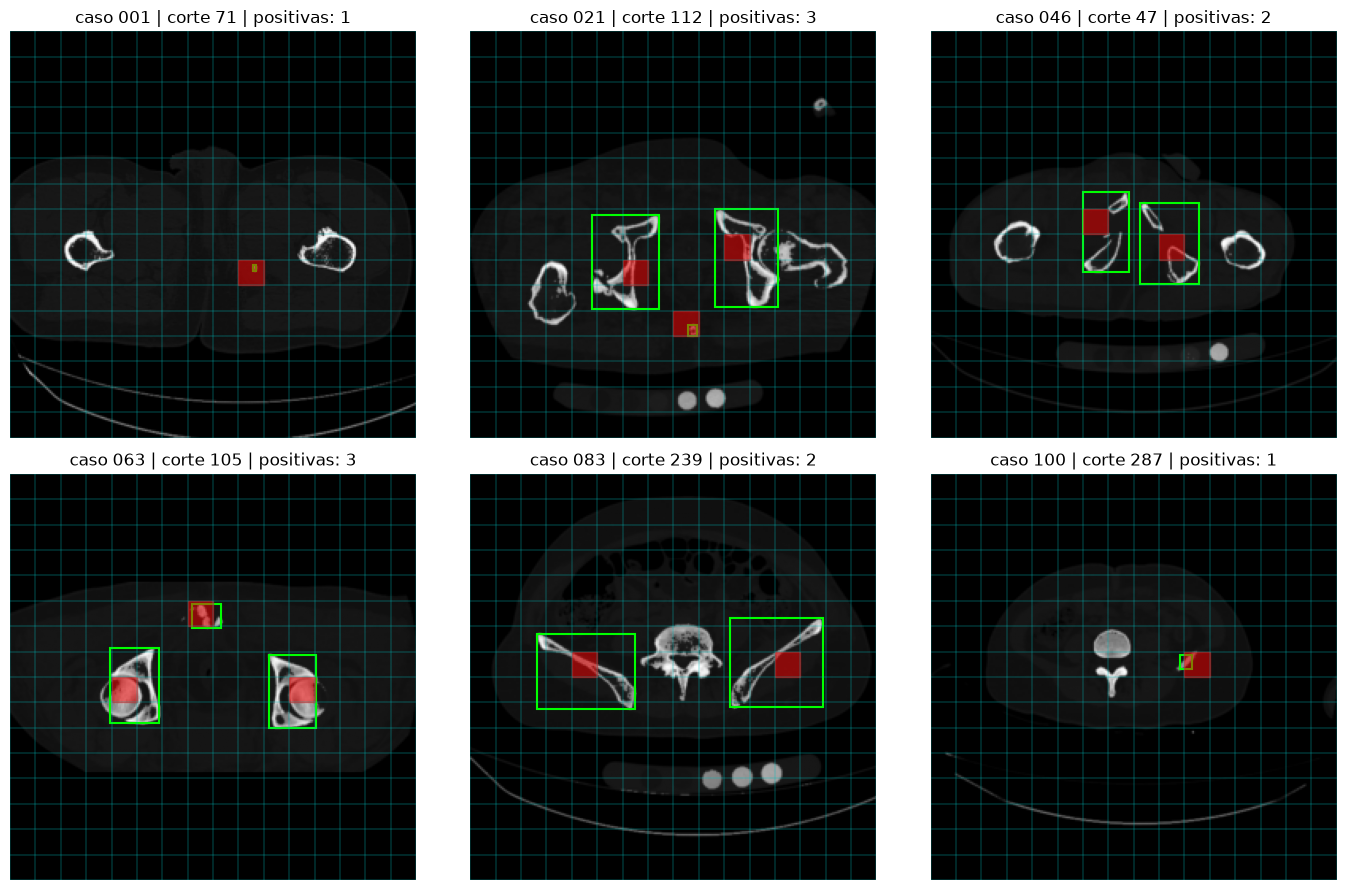

In [67]:
batch = torch.load("evidencias/batch_fijo.pt")      # ajusta la ruta si lo pusiste en otra carpeta
imgs = batch["imgs"]
targets = [{"boxes": b, "labels": l, "case_id": c, "slice_index": s}
           for b, l, c, s in zip(batch["boxes"], batch["labels"], batch["case_ids"], batch["slice_index"])]

T = build_targets(targets)
n_cajas = sum(len(t["boxes"]) for t in targets)
print(f"Imagenes: {len(targets)} | cajas GT: {n_cajas} | celdas positivas: {int(T['obj_t'].sum())} | colisiones: {T['n_collisions']}")
assert n_cajas == int(T["obj_t"].sum()) + T["n_collisions"], "las cuentas no cuadran"

for k, nombre in enumerate(["sacro", "coxal_izquierdo", "coxal_derecho"]):
    print(f"  {nombre:<16} celdas positivas: {int((T['cls_t'] == k).sum())}")

mask = T["obj_t"] == 1
tw_th = T["box_t"][mask][:, 2:]
print(f"Tamano relativo de las cajas (tw, th): min={tw_th.min():.3f}, max={tw_th.max():.3f}, media={tw_th.mean():.3f}")

# Figura: grid + cajas GT (verde) + celda responsable (rojo)
n = min(len(targets), 6)
fig, axes = plt.subplots(2, 3, figsize=(14, 9))
for ax in axes.ravel()[n:]:
    ax.axis("off")
for k, ax in zip(range(n), axes.ravel()):
    ax.imshow(imgs[k, 0], cmap="gray", vmin=0, vmax=1)
    for g in range(0, IMG_SIZE + 1, STRIDE):
        ax.axhline(g - 0.5, lw=0.3, c="c")
        ax.axvline(g - 0.5, lw=0.3, c="c")
    for b in targets[k]["boxes"]:
        ax.add_patch(Rectangle((b[0] - 0.5, b[1] - 0.5), b[2] - b[0], b[3] - b[1], fill=False, ec="lime", lw=1.5))
    pos = T["obj_t"][k].nonzero().tolist()
    for i, j in pos:
        ax.add_patch(Rectangle((j * STRIDE - 0.5, i * STRIDE - 0.5), STRIDE, STRIDE, fc="red", alpha=0.5, ec="red"))
    ax.set_title(f"caso {targets[k]['case_id']} | corte {targets[k]['slice_index']} | positivas: {len(pos)}")
    ax.axis("off")
plt.tight_layout()
plt.show()

### 4. la cabeza

La cabeza toma [B, 256, 16, 16] y devuelve logits crudos [B, 8, 16, 16], en el orden de canales que ya fijamos: 0 = objectness, 1–4 = tx, ty, tw, th, 5–7 = clases. Las sigmoides y el softmax se aplican en la pérdida y en la decodificación.

Decisiones del diseño:

- Conv 3×3 + GroupNorm + ReLU, y luego conv 1×1. Una 1×1 sola solo mira su propia celda, y tus cajas llegan a 62 px (cuatro celdas). La 3×3 deja que cada celda mire a sus vecinas. Uso GroupNorm y no BatchNorm porque no depende del batch ni tiene estadísticas acumuladas, así que no sufre la brecha train/eval que la Prueba 9 de Miguel midió en el backbone (98.6%).

- Bias iniciales con los datos que ya mediste:
Objectness en log(0.008/0.992) ≈ −4.8. Es la fracción de positivas que mediste (0.78%), así que la pérdida no arranca con miles de falsos positivos.
tw, th en log(0.13/0.87) ≈ −1.9, que equivale al tamaño medio de tus cajas (0.133).
tx, ty en 0, que da la mitad de la celda (0.5).

- El wrapper GridDetector une backbone → CBAM (opcional) → cabeza. Recuerda que el CBAM devuelve tres cosas y aquí solo se usa la primera. Con él, probar base y plus, con y sin CBAM, es una línea.

In [81]:
import math

class GridDetectionHead(nn.Module):
    """Cabeza de deteccion tipo grid. Entrada [B, C, S, S] -> logits crudos [B, 8, S, S].
    canal 0 = objectness | canales 1-4 = tx, ty, tw, th | canales 5-7 = clases."""
    def __init__(self, in_channels=256, hidden=128, num_classes=3, obj_prior=0.008, wh_prior=0.13):
        super().__init__()
        self.num_classes = num_classes
        self.conv = nn.Sequential(
            nn.Conv2d(in_channels, hidden, kernel_size=3, padding=1, bias=False),
            nn.GroupNorm(8, hidden),          # independiente del batch: sin brecha train/eval
            nn.ReLU(inplace=True),
        )
        self.pred = nn.Conv2d(hidden, 1 + 4 + num_classes, kernel_size=1)
        with torch.no_grad():
            self.pred.bias.zero_()                                           # tx, ty -> sigmoide(0) = 0.5 (centro de la celda)
            self.pred.bias[CH_OBJ] = math.log(obj_prior / (1 - obj_prior))   # ~ -4.8 -> ~0.8% de prob. inicial de objeto
            self.pred.bias[3:5] = math.log(wh_prior / (1 - wh_prior))        # tw, th ~ -1.9 -> ~0.13 de la imagen

    def forward(self, x):
        return self.pred(self.conv(x))


def split_head_output(out):
    """[B,8,S,S] -> obj_logit [B,S,S], box_logit [B,S,S,4], cls_logit [B,S,S,C]
    (mismo orden de celdas que los tensores de build_targets)."""
    obj_logit = out[:, CH_OBJ]
    box_logit = out[:, CH_BOX].permute(0, 2, 3, 1)
    cls_logit = out[:, CH_CLS].permute(0, 2, 3, 1)
    return obj_logit, box_logit, cls_logit


class GridDetector(nn.Module):
    """backbone -> (CBAM con compuerta residual, opcional) -> cabeza."""
    def __init__(self, backbone, head, cbam=None):
        super().__init__()
        self.backbone, self.cbam, self.head = backbone, cbam, head

    def forward(self, x):
        _, fmap = self.backbone(x)
        if self.cbam is not None:
            fmap, _, _ = self.cbam(fmap)   
        return self.head(fmap)

def build_detector(backbone_name="base", use_cbam=True):
    torch.manual_seed(SEED)
    backbone = build_backbone(backbone_name, in_channels=1)
    cbam = CompuertaResidualCBAM(CBAM(256)) if use_cbam else None
    torch.manual_seed(SEED)             
    head = GridDetectionHead()
    return GridDetector(backbone, head, cbam).to(DEVICE)

# ---------------- Pruebas de control ----------------
fallas4 = []

def check4(nombre, ok, detalle=""):
    print(f"{'OK   ' if ok else 'FALLA'} | {nombre:<60} {detalle}")
    if not ok:
        fallas4.append(nombre)

x = imgs.to(DEVICE)                 # batch real de Cell B: [6, 1, 256, 256]
B = x.shape[0]

# 1) Forma de la salida y valores finitos, para las 4 combinaciones
for bb in ["base", "plus"]:
    for use_cbam in [False, True]:
        det = build_detector(bb, use_cbam).eval()
        with torch.no_grad():
            out = det(x)
        ok = tuple(out.shape) == (B, 8, GRID_S, GRID_S) and bool(torch.isfinite(out).all())
        check4(f"1. salida [B,8,16,16] y finita | {bb:<4} | cbam={use_cbam}", ok, f"obtenido={tuple(out.shape)}")

# 2) Priors al inicio (cotas holgadas a proposito: hay algo de ruido por los pesos aleatorios)
det = build_detector("base", True).eval()
with torch.no_grad():
    out = det(x)
obj_logit, box_logit, cls_logit = split_head_output(out)
p_obj = torch.sigmoid(obj_logit).mean().item()
p_xy = torch.sigmoid(box_logit[..., :2]).mean().item()
p_wh = torch.sigmoid(box_logit[..., 2:]).mean().item()
check4("2. prob. media de objeto ~ 0.008 (cota [0.002, 0.05])", 0.002 < p_obj < 0.05, f"obtenido={p_obj:.4f}")
check4("2b. tw,th medios ~ 0.13 (cota [0.08, 0.20])", 0.08 < p_wh < 0.20, f"obtenido={p_wh:.3f}")
check4("2c. tx,ty medios ~ 0.5 (cota [0.4, 0.6])", 0.4 < p_xy < 0.6, f"obtenido={p_xy:.3f}")

# 3) Orden de canales y compatibilidad con los targets de build_targets
check4("3. split: formas [B,S,S], [B,S,S,4], [B,S,S,3]",
       tuple(obj_logit.shape) == (B, GRID_S, GRID_S) and tuple(box_logit.shape) == (B, GRID_S, GRID_S, 4)
       and tuple(cls_logit.shape) == (B, GRID_S, GRID_S, 3))
check4("3b. split: canales en su sitio (obj=0, tw=3, clase 1 = 6)",
       torch.equal(obj_logit, out[:, 0]) and torch.equal(box_logit[..., 2], out[:, 3]) and torch.equal(cls_logit[..., 1], out[:, 6]))
T4 = build_targets(targets)
check4("3c. mismas formas que los targets (obj_t, box_t, cls_t)",
       T4["obj_t"].shape == obj_logit.shape and T4["box_t"].shape == box_logit.shape and T4["cls_t"].shape == cls_logit.shape[:-1])

# 4) Numero de parametros (son entregable)
n_head = count_parameters(det.head)
check4("4. parametros de la cabeza = 296,200", n_head == 296_200, f"obtenido={n_head:,}")
check4("4b. total base+CBAM+cabeza = 693,290", count_parameters(det) == 388_800 + 8_290 + 296_200 + 1, f"obtenido={count_parameters(det):,}")
n_plus = count_parameters(build_detector("plus", True))
check4("4c. total plus+CBAM+cabeza = 1,873,962", n_plus == 1_569_472 + 8_290 + 296_200 + 1, f"obtenido={n_plus:,}")

# 5) Gradientes de punta a punta (modo entrenamiento)
det = build_detector("base", True).train()
det.zero_grad()
det(x).mean().backward()
malos = [n for n, p in det.head.named_parameters() if p.grad is None or not torch.isfinite(p.grad).all()]
check4("5. todos los parametros de la cabeza reciben gradiente finito", len(malos) == 0, f"sin gradiente: {malos}" if malos else "")
g1 = det.backbone.conv1.weight.grad
check4("5b. el gradiente llega hasta conv1 del backbone", g1 is not None and g1.norm().item() > 0,
       f"norma={g1.norm().item():.3e}" if g1 is not None else "")
for nombre, mod in [("conv 3x3", det.head.conv[0]), ("conv 1x1 (pred)", det.head.pred)]:
    print(f"      norma de gradiente {nombre:<16}: {mod.weight.grad.norm().item():.3e}")

# 6) Reproducibilidad: misma semilla -> mismas salidas
with torch.no_grad():
    o1 = build_detector("base", True).eval()(x)
    o2 = build_detector("base", True).eval()(x)
check4("6. misma semilla -> salidas identicas", torch.equal(o1, o2))

print()
print("TODAS LAS PRUEBAS PASARON" if not fallas4 else f"FALLARON: {fallas4}")

OK    | 1. salida [B,8,16,16] y finita | base | cbam=False           obtenido=(6, 8, 16, 16)
OK    | 1. salida [B,8,16,16] y finita | base | cbam=True            obtenido=(6, 8, 16, 16)
OK    | 1. salida [B,8,16,16] y finita | plus | cbam=False           obtenido=(6, 8, 16, 16)
OK    | 1. salida [B,8,16,16] y finita | plus | cbam=True            obtenido=(6, 8, 16, 16)
OK    | 2. prob. media de objeto ~ 0.008 (cota [0.002, 0.05])        obtenido=0.0078
OK    | 2b. tw,th medios ~ 0.13 (cota [0.08, 0.20])                  obtenido=0.156
FALLA | 2c. tx,ty medios ~ 0.5 (cota [0.4, 0.6])                     obtenido=0.635
OK    | 3. split: formas [B,S,S], [B,S,S,4], [B,S,S,3]               
OK    | 3b. split: canales en su sitio (obj=0, tw=3, clase 1 = 6)    
OK    | 3c. mismas formas que los targets (obj_t, box_t, cls_t)      
OK    | 4. parametros de la cabeza = 296,200                         obtenido=296,200
OK    | 4b. total base+CBAM+cabeza = 693,290                         obtenido=6

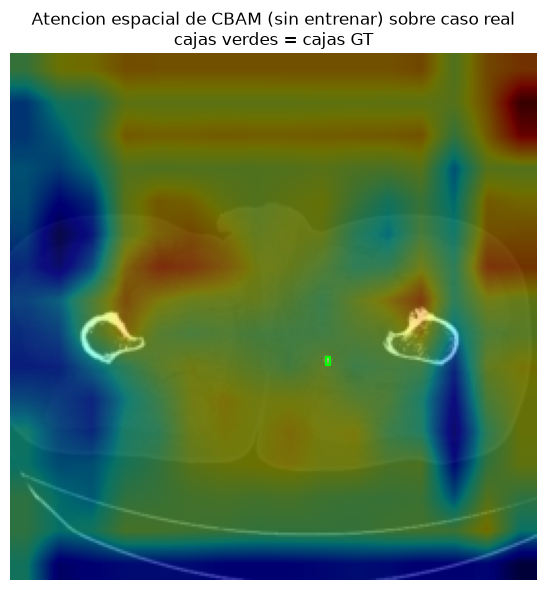

In [82]:
# Usa el batch_fijo real (ya regenerado con CLAHE+Otsu) que cargaste en la celda 28
det_demo = build_detector("base", use_cbam=True).eval()

idx_demo = 0  # elige cualquier imagen del batch, 0-5
img_demo = imgs[idx_demo:idx_demo+1].to(DEVICE)

with torch.no_grad():
    _, fmap_demo = det_demo.backbone(img_demo)
    _, _, sp_attn_demo = det_demo.cbam.cbam(fmap_demo)  # atencion espacial cruda (16x16)

# Sube el mapa de 16x16 a 256x256 para superponerlo sobre la imagen
sp_attn_upsampled = F.interpolate(sp_attn_demo, size=256, mode="bilinear", align_corners=False)[0, 0].cpu()

fig, ax = plt.subplots(1, 1, figsize=(6, 6))
ax.imshow(imgs[idx_demo, 0], cmap="gray")
ax.imshow(sp_attn_upsampled, cmap="jet", alpha=0.45)
for b in targets[idx_demo]["boxes"]:
    ax.add_patch(Rectangle((b[0], b[1]), b[2]-b[0], b[3]-b[1], fill=False, ec="lime", lw=1.5))
ax.set_title(f"Atencion espacial de CBAM (sin entrenar) sobre caso real\ncajas verdes = cajas GT")
ax.axis("off")
plt.tight_layout()
plt.show()

In [83]:
# Prueba: con gamma=0 la compuerta residual no debe alterar la salida de la cabeza
det_con_cbam = build_detector("base", use_cbam=True).eval()
det_sin_cbam = build_detector("base", use_cbam=False).eval()

with torch.no_grad():
    x_check = torch.rand(4, 1, 256, 256, device=DEVICE)
    out_con = det_con_cbam(x_check)
    out_sin = det_sin_cbam(x_check)

gamma_inicial = det_con_cbam.cbam.gamma.item()
identico = torch.allclose(out_con, out_sin, atol=1e-5)

print(f"gamma al inicio: {gamma_inicial:.6f} (debe ser 0)")
print(f"Salida identica con y sin CBAM al inicio: {identico}")
assert gamma_inicial == 0.0
assert identico, "la compuerta residual deberia dar salida identica cuando gamma=0"

gamma al inicio: 0.000000 (debe ser 0)
Salida identica con y sin CBAM al inicio: True


### Paso 5: Las tres pérdidas

Cada pérdida mira una parte distinta de la salida y compara contra los tensores de `build_targets`:

| Pérdida | ¿Qué mide? | ¿Dónde se calcula? |
| :--- | :--- | :--- |
| **`obj`** | ¿Hay hueso aquí? | Todas las celdas |
| **`box`** | ¿Dónde está su caja? | Solo celdas positivas |
| **`cls`** | ¿Qué hueso es? | Solo celdas positivas |

**Nota:** La regla de que el fondo no cuenta para caja y clase aplica a las dos últimas (`box` y `cls`). `obj` (Objectness) sí mira todo, porque si no, el modelo nunca aprendería a decir *"aquí no hay nada"*.

In [76]:
LAMBDAS = {"obj": 1.0, "box": 1.0, "cls": 1.0,   # pesos de las 3 perdidas (los que se calibran y justifican en el informe)
           "noobj": 1.0,                          # peso de los negativos dentro de la perdida de objectness
           "l1": 1.0, "iou": 1.0}                 # peso de cada parte de la perdida de caja


def grid_detection_loss(out, tgt, lambdas=LAMBDAS):
    """out: logits crudos [B,8,S,S] (salida de GridDetector). tgt: dict de build_targets.
    Devuelve un dict de tensores: total, obj, obj_pos, obj_neg, box, box_l1, box_iou, cls, mean_iou, n_pos."""
    out = out.float()                                    # perdidas siempre en float32 (compatible con AMP)
    obj_logit, box_logit, cls_logit = split_head_output(out)
    obj_t = tgt["obj_t"].to(out.device)
    box_t = tgt["box_t"].to(out.device)
    cls_t = tgt["cls_t"].to(out.device)

    pos = obj_t > 0.5                                    # [B,S,S] celdas con objeto
    n_pos = pos.sum().clamp(min=1).float()               # clamp: sin cajas no se divide entre 0
    n_neg = (~pos).sum().clamp(min=1).float()

    # 1) Objectness: TODAS las celdas; positivos y negativos se promedian por separado
    bce = F.binary_cross_entropy_with_logits(obj_logit, obj_t, reduction="none")
    obj_pos = bce[pos].sum() / n_pos
    obj_neg = bce[~pos].sum() / n_neg
    obj = obj_pos + lambdas["noobj"] * obj_neg

    # 2) Caja y 3) clase: SOLO celdas positivas
    b, r, c = pos.nonzero(as_tuple=True)
    t_pred = torch.sigmoid(box_logit[b, r, c])           # [N,4] tx,ty,tw,th predichos
    t_gt = box_t[b, r, c]                                # [N,4] los de la caja real
    box_l1 = (t_pred - t_gt).abs().sum() / (4 * n_pos)
    iou = box_iou(decode_boxes(r, c, t_pred), decode_boxes(r, c, t_gt))   # [N] en pixeles
    box_iou_loss = (1 - iou).sum() / n_pos
    box = lambdas["l1"] * box_l1 + lambdas["iou"] * box_iou_loss

    if b.numel() == 0:
        cls = cls_logit.sum() * 0.0                      # sin positivas: 0, pero conectado al grafo
    else:
        cls = F.cross_entropy(cls_logit[b, r, c], cls_t[b, r, c], reduction="sum") / n_pos

    total = lambdas["obj"] * obj + lambdas["box"] * box + lambdas["cls"] * cls
    mean_iou = iou.detach().mean() if iou.numel() > 0 else torch.zeros((), device=out.device)
    return {"total": total, "obj": obj, "obj_pos": obj_pos, "obj_neg": obj_neg,
            "box": box, "box_l1": box_l1, "box_iou": box_iou_loss,
            "cls": cls, "mean_iou": mean_iou, "n_pos": pos.sum()}


# ---------------- Pruebas de control ----------------
fallas5 = []

def check5(nombre, ok, detalle=""):
    print(f"{'OK   ' if ok else 'FALLA'} | {nombre:<62} {detalle}")
    if not ok:
        fallas5.append(nombre)

x = imgs.to(DEVICE)                     # batch real: [6, 1, 256, 256]
T5 = build_targets(targets)
LOSS = grid_detection_loss


def logits_perfectos(T):
    """Logits que reproducen los targets casi exactamente (para comprobar que la perdida llega a ~0)."""
    obj_t, box_t, cls_t = T["obj_t"], T["box_t"], T["cls_t"]
    B_, S_ = obj_t.shape[0], obj_t.shape[1]
    pos = obj_t > 0.5
    out = torch.zeros(B_, 8, S_, S_)
    out[:, CH_OBJ] = pos.float() * 40 - 20               # +20 donde hay objeto, -20 en el fondo
    t = box_t.clamp(1e-4, 1 - 1e-4)
    out[:, CH_BOX] = torch.log(t / (1 - t)).permute(0, 3, 1, 2)   # inversa de la sigmoide
    b, r, c = pos.nonzero(as_tuple=True)
    out[b, 5 + cls_t[b, r, c], r, c] = 20.0              # clase correcta con logit alto
    return out.to(DEVICE)


pos5 = (T5["obj_t"] > 0.5)
bb, rr, cc = pos5.nonzero(as_tuple=True)

# 1) Con el modelo real: finita y total = suma ponderada
det = build_detector("base", True).train()
out_real = det(x)
L = LOSS(out_real, T5)
vals = [L[k].item() for k in ("total", "obj", "box", "cls")]
check5("1. perdidas finitas con el batch real", all(math.isfinite(v) for v in vals), f"total={vals[0]:.3f} obj={vals[1]:.3f} box={vals[2]:.3f} cls={vals[3]:.3f}")
check5("1b. total = obj + box + cls (todos los lambda en 1)", abs(L["total"].item() - (vals[1] + vals[2] + vals[3])) < 1e-4)
lam2 = {"obj": 2.0, "box": 3.0, "cls": 5.0, "noobj": 1.0, "l1": 1.0, "iou": 1.0}
L2 = LOSS(out_real, T5, lam2)
check5("1c. los lambda se aplican: total = 2*obj + 3*box + 5*cls", abs(L2["total"].item() - (2 * L2["obj"].item() + 3 * L2["box"].item() + 5 * L2["cls"].item())) < 1e-4)

# 2) Predicciones perfectas -> perdida ~ 0 e IoU ~ 1
Lp = LOSS(logits_perfectos(T5), T5)
check5("2. logits perfectos: total ~ 0", Lp["total"].item() < 1e-2, f"total={Lp['total'].item():.2e}")
check5("2b. logits perfectos: IoU medio ~ 1", Lp["mean_iou"].item() > 0.99, f"IoU medio={Lp['mean_iou'].item():.4f}")

# 3) REGLA CLAVE: el fondo se ignora en caja y clase
torch.manual_seed(SEED)
out_a = logits_perfectos(T5)
out_b = out_a.clone()
fondo = (~pos5).unsqueeze(1).expand(-1, 7, -1, -1).to(DEVICE)         # canales 1..7 en celdas de fondo
out_b[:, 1:] = torch.where(fondo, torch.randn_like(out_b[:, 1:]) * 10, out_b[:, 1:])
La, Lb = LOSS(out_a, T5), LOSS(out_b, T5)
same_box = all(torch.allclose(La[k], Lb[k], atol=1e-6) for k in ("box", "box_l1", "box_iou"))
check5("3. basura en caja del FONDO: la perdida de caja no cambia", same_box)
check5("3b. basura en clase del FONDO: la perdida de clase no cambia", torch.allclose(La["cls"], Lb["cls"], atol=1e-6))
out_c = out_a.clone()
out_c[:, CH_OBJ] = torch.where(pos5.to(DEVICE), out_c[:, CH_OBJ], torch.full_like(out_c[:, CH_OBJ], 5.0))
Lc = LOSS(out_c, T5)
check5("3c. objectness SI mira el fondo: falsos positivos suben obj_neg", Lc["obj_neg"].item() > 4.0, f"obj_neg={Lc['obj_neg'].item():.2f}")

# 4) En las celdas positivas, equivocarse SI cuesta
out_d = out_a.clone()
out_d[bb, 5 + (T5["cls_t"][bb, rr, cc] + 1) % 3, rr, cc] = 30.0       # clase equivocada con logit alto
Ld = LOSS(out_d, T5)
check5("4. clase equivocada en celdas positivas: cls sube mucho", Ld["cls"].item() > 5.0, f"cls={Ld['cls'].item():.2f}")
out_e = out_a.clone()
out_e[bb, 3, rr, cc] = -5.0
out_e[bb, 4, rr, cc] = -5.0                                           # cajas diminutas
Le = LOSS(out_e, T5)
check5("4b. caja diminuta en celdas positivas: box_iou sube mucho", Le["box_iou"].item() > 0.5, f"box_iou={Le['box_iou'].item():.3f}")

# 5) Estabilidad numerica
Lx = LOSS(torch.randn(len(targets), 8, GRID_S, GRID_S) * 1e3, T5)
check5("5. logits extremos (+-1000): todas las perdidas finitas", all(torch.isfinite(v).all().item() for v in Lx.values()))
Lh = LOSS(torch.randn(len(targets), 8, GRID_S, GRID_S).half(), T5)
check5("5b. entrada float16 (como bajo AMP): perdidas finitas", all(torch.isfinite(v).all().item() for v in Lh.values()))

# 6) Batch sin cajas
T_vacio = build_targets([{"boxes": torch.zeros((0, 4)), "labels": torch.zeros((0,), dtype=torch.long)}])
out_v = torch.randn(1, 8, GRID_S, GRID_S, requires_grad=True)
Lv = LOSS(out_v, T_vacio)
check5("6. sin cajas: box = 0, cls = 0, total finito",
       Lv["box"].item() == 0.0 and Lv["cls"].item() == 0.0 and math.isfinite(Lv["total"].item()), f"total={Lv['total'].item():.3f}")
Lv["total"].backward()
check5("6b. sin cajas: el backward funciona y el gradiente es finito", out_v.grad is not None and bool(torch.isfinite(out_v.grad).all()))

# 7) Cada perdida entrena SOLO su parte de la salida (se ve en el bias de la capa final)
def grad_bias(term):
    d = build_detector("base", True).train()
    d.zero_grad()
    LOSS(d(x), T5)[term].backward()
    return d.head.pred.bias.grad.clone()

g_obj, g_box, g_cls = grad_bias("obj"), grad_bias("box"), grad_bias("cls")
check5("7. obj: gradiente solo en el canal 0", g_obj[0].abs().item() > 0 and g_obj[1:].abs().max().item() == 0.0)
check5("7b. box: gradiente solo en los canales 1-4", bool((g_box[1:5].abs() > 0).all()) and g_box[0].abs().item() == 0.0 and g_box[5:].abs().max().item() == 0.0)
check5("7c. cls: gradiente solo en los canales 5-7", g_cls[5:].abs().sum().item() > 0 and g_cls[:5].abs().max().item() == 0.0)

print()
print("TODAS LAS PRUEBAS PASARON" if not fallas5 else f"FALLARON: {fallas5}")

# 8) Magnitudes iniciales y lambda sugeridos por equilibrio (informativo, no es una prueba)
det = build_detector("base", True).train()
with torch.no_grad():
    Li = LOSS(det(x), T5)
print("\n--- Desglose al inicializar (base + CBAM, batch real) ---")
for k in ("obj_pos", "obj_neg", "box_l1", "box_iou", "cls", "mean_iou"):
    print(f"  {k:<9} {Li[k].item():.4f}")
mags = {"obj": Li["obj"].item(), "box": Li["box"].item(), "cls": Li["cls"].item()}
media = sum(mags.values()) / 3
print("\n--- Equilibrio de magnitudes: lambda_k = media / L_k (punto de partida, no valor final) ---")
for k, m in mags.items():
    print(f"  {k:<4} L_inicial={m:.3f}  lambda sugerido={media / m:.2f}")

OK    | 1. perdidas finitas con el batch real                          total=6.592 obj=4.273 box=0.984 cls=1.334
OK    | 1b. total = obj + box + cls (todos los lambda en 1)            
OK    | 1c. los lambda se aplican: total = 2*obj + 3*box + 5*cls       
OK    | 2. logits perfectos: total ~ 0                                 total=1.36e-08
OK    | 2b. logits perfectos: IoU medio ~ 1                            IoU medio=1.0000
OK    | 3. basura en caja del FONDO: la perdida de caja no cambia      
OK    | 3b. basura en clase del FONDO: la perdida de clase no cambia   
OK    | 3c. objectness SI mira el fondo: falsos positivos suben obj_neg obj_neg=5.01
OK    | 4. clase equivocada en celdas positivas: cls sube mucho        cls=10.00
OK    | 4b. caja diminuta en celdas positivas: box_iou sube mucho      box_iou=0.958
OK    | 5. logits extremos (+-1000): todas las perdidas finitas        
OK    | 5b. entrada float16 (como bajo AMP): perdidas finitas          
OK    | 6. sin cajas: box = 0,

### 6. interfaz para el NMS

In [77]:
CLASS_NAMES = {1: "sacro", 2: "coxal_izquierdo", 3: "coxal_derecho"}   # misma convencion de labels que Daniela


@torch.no_grad()
def decode_predictions(out, score_thresh=0.0, img_size=IMG_SIZE):
    """Logits crudos [B,8,S,S] -> lista de B dicts con candidatas ordenadas por score (de mayor a menor):
      boxes [N,4] xyxy en px (recortadas a la imagen) | scores [N] = objectness * prob. de clase
      labels [N] en 1..3 (convencion de Daniela)       | cells [N,2] = (row, col) de la celda de origen"""
    out = out.float()
    obj_logit, box_logit, cls_logit = split_head_output(out)
    B, S = obj_logit.shape[0], obj_logit.shape[1]
    cls_score, cls_idx = torch.softmax(cls_logit, dim=-1).max(dim=-1)        # [B,S,S]
    score = torch.sigmoid(obj_logit) * cls_score                             # [B,S,S]
    t = torch.sigmoid(box_logit)                                             # [B,S,S,4]

    rows = torch.arange(S, device=out.device).view(S, 1).expand(S, S).reshape(-1)
    cols = torch.arange(S, device=out.device).view(1, S).expand(S, S).reshape(-1)

    results = []
    for b in range(B):
        boxes = decode_boxes(rows, cols, t[b].reshape(-1, 4), img_size, S).clamp(0, img_size)
        sc = score[b].reshape(-1)
        lb = cls_idx[b].reshape(-1) + 1                                      # 0..2 -> 1..3
        keep = (sc >= score_thresh).nonzero(as_tuple=True)[0]
        keep = keep[sc[keep].argsort(descending=True)]                       # el NMS parte de scores ordenados
        results.append({"boxes": boxes[keep], "scores": sc[keep], "labels": lb[keep],
                        "cells": torch.stack([rows[keep], cols[keep]], dim=1)})
    return results


def postprocess(out, score_thresh=0.05, nms_fn=None, iou_thresh=0.5, img_size=IMG_SIZE):
    """decode_predictions + NMS opcional.
    nms_fn(boxes [N,4], scores [N], labels [N], iou_thresh) -> LongTensor con los indices a conservar.
    Sin nms_fn devuelve todas las candidatas sobre score_thresh."""
    preds = decode_predictions(out, score_thresh, img_size)
    if nms_fn is None:
        return preds
    final = []
    for p in preds:
        keep = nms_fn(p["boxes"], p["scores"], p["labels"], iou_thresh)
        final.append({k: v[keep] for k, v in p.items()})
    return final


# ---------------- Pruebas de control ----------------
fallas6 = []

def check6(nombre, ok, detalle=""):
    print(f"{'OK   ' if ok else 'FALLA'} | {nombre:<64} {detalle}")
    if not ok:
        fallas6.append(nombre)

def empareja(pred, gt_boxes, gt_labels):
    """Cada prediccion cae sobre una caja real distinta (IoU > 0.99) y con su misma clase."""
    M = pairwise_iou(pred["boxes"], gt_boxes)
    best_iou, j = M.max(dim=1)
    return (bool((best_iou > 0.99).all()) and bool((pred["labels"] == gt_labels[j]).all())
            and len(set(j.tolist())) == len(gt_boxes))

# 1) Logits perfectos -> el decodificador recupera exactamente las cajas y clases del GT
preds = decode_predictions(logits_perfectos(T5), score_thresh=0.5)
check6("1. logits perfectos: mismo numero de cajas que el GT en cada imagen",
       all(len(preds[k]["boxes"]) == len(targets[k]["boxes"]) for k in range(len(targets))),
       f"preds={[len(p['boxes']) for p in preds]} GT={[len(t['boxes']) for t in targets]}")
check6("1b. logits perfectos: cajas (IoU > 0.99) y clases coinciden con el GT",
       all(empareja(preds[k], targets[k]["boxes"].to(DEVICE), targets[k]["labels"].to(DEVICE)) for k in range(len(targets))))

# 2) Formato con el modelo sin entrenar y umbral 0 (todas las celdas son candidatas)
det = build_detector("base", True).eval()
with torch.no_grad():
    out_r = det(x)
p_all = decode_predictions(out_r, score_thresh=0.0)
S2 = GRID_S * GRID_S
check6("2. umbral 0: 256 candidatas por imagen con las formas correctas",
       all(p["boxes"].shape == (S2, 4) and p["scores"].shape == (S2,) and p["labels"].shape == (S2,) and p["cells"].shape == (S2, 2) for p in p_all))
check6("2b. scores en [0,1], labels en {1,2,3}, celdas en [0,15]",
       all(bool((p["scores"] >= 0).all() and (p["scores"] <= 1).all()) and set(p["labels"].tolist()) <= {1, 2, 3}
           and int(p["cells"].min()) >= 0 and int(p["cells"].max()) <= GRID_S - 1 for p in p_all))
check6("2c. candidatas ordenadas por score (de mayor a menor)",
       all(bool((p["scores"][:-1] >= p["scores"][1:]).all()) for p in p_all))

# 3) Umbral imposible -> listas vacias pero con la forma correcta (no deben fallar)
p_vacio = decode_predictions(out_r, score_thresh=2.0)
check6("3. umbral imposible: boxes [0,4], scores [0], cells [0,2]",
       all(p["boxes"].shape == (0, 4) and p["scores"].shape == (0,) and p["cells"].shape == (0, 2) for p in p_vacio))

# 4) Logits extremos: las cajas deben seguir dentro de la imagen
p_ext = decode_predictions(torch.randn(len(targets), 8, GRID_S, GRID_S, device=DEVICE) * 10, score_thresh=0.0)
check6("4. logits extremos: cajas recortadas a [0, 256]", all(float(p["boxes"].min()) >= 0 and float(p["boxes"].max()) <= IMG_SIZE for p in p_ext))

# 5) float16 (como bajo AMP) y batch de una sola imagen
p_h = decode_predictions(out_r[:1].half(), score_thresh=0.0)
check6("5. float16 y B=1: devuelve 1 dict, valores finitos",
       len(p_h) == 1 and bool(torch.isfinite(p_h[0]["boxes"]).all()) and bool(torch.isfinite(p_h[0]["scores"]).all()))

# 6) El enchufe del NMS funciona (con NMS de juguete: conserva solo la mejor candidata)
def nms_juguete(boxes, scores, labels, iou_thresh):
    return torch.arange(min(1, len(scores)), device=scores.device)

p_sin = postprocess(out_r, score_thresh=0.0)
p_con = postprocess(out_r, score_thresh=0.0, nms_fn=nms_juguete)
check6("6. sin nms_fn devuelve todas las candidatas (256 por imagen)", all(len(p["boxes"]) == S2 for p in p_sin))
check6("6b. con nms_fn conserva solo las que elige y mantiene todas las llaves",
       all(len(p["boxes"]) == 1 and set(p.keys()) == {"boxes", "scores", "labels", "cells"} for p in p_con))
p_keep_all = postprocess(logits_perfectos(T5), score_thresh=0.5, nms_fn=lambda b, s, l, t: torch.arange(len(s), device=s.device))
check6("6c. nms_fn que conserva todo no cambia el resultado",
       all(len(p_keep_all[k]["boxes"]) == len(targets[k]["boxes"]) for k in range(len(targets))))
p_nms_vacio = postprocess(out_r, score_thresh=2.0, nms_fn=nms_juguete)
check6("6d. NMS sobre una imagen sin candidatas no falla", all(p["boxes"].shape == (0, 4) for p in p_nms_vacio))

print()
print("TODAS LAS PRUEBAS PASARON" if not fallas6 else f"FALLARON: {fallas6}")

OK    | 1. logits perfectos: mismo numero de cajas que el GT en cada imagen preds=[1, 3, 2, 3, 2, 1] GT=[1, 3, 2, 3, 2, 1]
OK    | 1b. logits perfectos: cajas (IoU > 0.99) y clases coinciden con el GT 
OK    | 2. umbral 0: 256 candidatas por imagen con las formas correctas  
OK    | 2b. scores en [0,1], labels en {1,2,3}, celdas en [0,15]         
OK    | 2c. candidatas ordenadas por score (de mayor a menor)            
OK    | 3. umbral imposible: boxes [0,4], scores [0], cells [0,2]        
OK    | 4. logits extremos: cajas recortadas a [0, 256]                  
OK    | 5. float16 y B=1: devuelve 1 dict, valores finitos               
OK    | 6. sin nms_fn devuelve todas las candidatas (256 por imagen)     
OK    | 6b. con nms_fn conserva solo las que elige y mantiene todas las llaves 
OK    | 6c. nms_fn que conserva todo no cambia el resultado              
OK    | 6d. NMS sobre una imagen sin candidatas no falla                 

TODAS LAS PRUEBAS PASARON


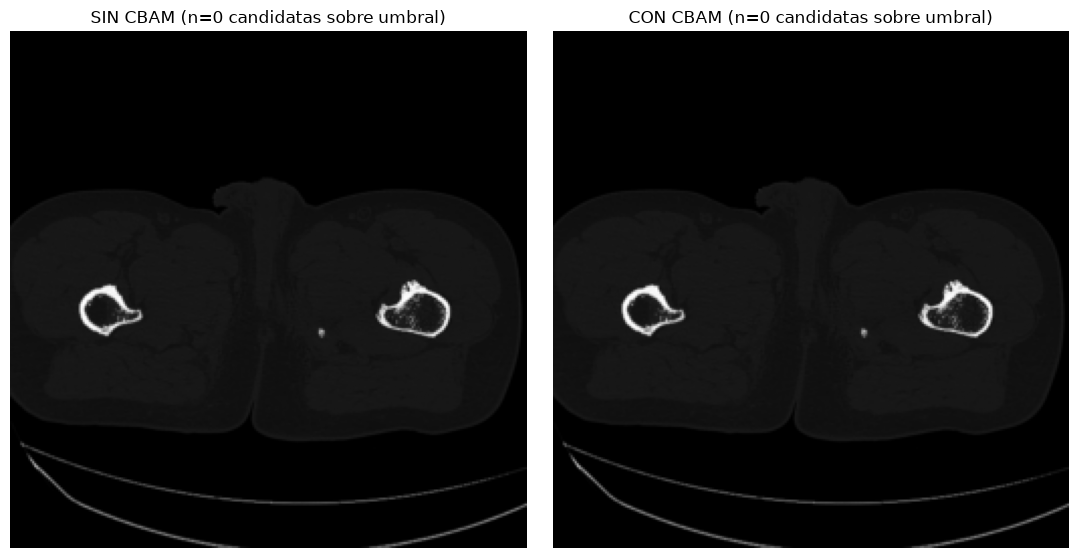

In [78]:
det_con = build_detector("base", use_cbam=True).eval()
det_sin = build_detector("base", use_cbam=False).eval()

idx_comp = 0
img_comp = imgs[idx_comp:idx_comp+1].to(DEVICE)

with torch.no_grad():
    out_con = det_con(img_comp)
    out_sin = det_sin(img_comp)

preds_con = decode_predictions(out_con, score_thresh=0.3)[0]
preds_sin = decode_predictions(out_sin, score_thresh=0.3)[0]

fig, axes = plt.subplots(1, 2, figsize=(11, 5.5))
for ax, preds, titulo in [(axes[0], preds_sin, "SIN CBAM"), (axes[1], preds_con, "CON CBAM")]:
    ax.imshow(imgs[idx_comp, 0], cmap="gray")
    for box in preds["boxes"][:10]:  # top 10 por score, para no saturar la imagen
        ax.add_patch(Rectangle((box[0], box[1]), box[2]-box[0], box[3]-box[1], fill=False, ec="orange", lw=1))
    ax.set_title(f"{titulo} (n={len(preds['boxes'])} candidatas sobre umbral)")
    ax.axis("off")
plt.tight_layout()
plt.show()